## HW 2 Markov Processes<br>
Filippa Mudsam

### Assignment 3 <br>
**part c**

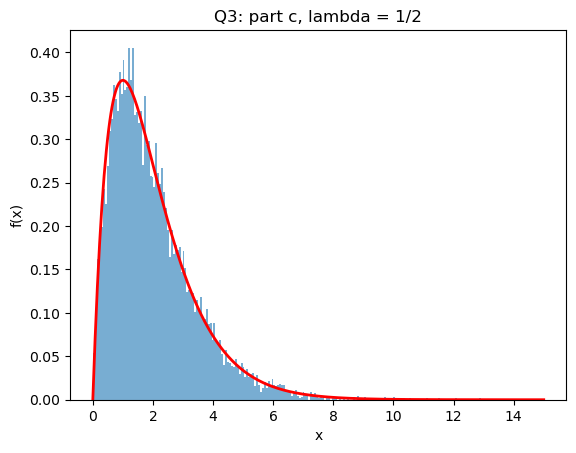

In [98]:
import numpy as np
import matplotlib.pyplot as plt

def run_accept_reject(lam, c, N, seed=0):
    rng = np.random.default_rng(seed)
    samples = np.zeros(N)
    n_accepted = 0
    n_proposed = 0

    while n_accepted < N:
        U1 = rng.uniform(0, 1)
        X = -np.log(1 - U1) / lam
        fX = X * np.exp(-X)
        gX = lam * np.exp(-lam * X)
        U2 = rng.uniform(0, 1)
        n_proposed += 1
        if U2 <= fX / (c * gX):
            samples[n_accepted] = X
            n_accepted += 1

    return samples, n_accepted/n_proposed

lam = 0.5
c = 4/np.e
N = 10**4

samples, acc_frac = run_accept_reject(lam, c, N)

x = np.linspace(0, 15, 400)
f = x * np.exp(-x)



plt.hist(samples, bins=200, density=True, alpha=0.6, label='Empirical pdf')
plt.plot(x, f, 'r-', linewidth=2, label='True Gamma(2,1) density')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Q3: part c, lambda = 1/2')
plt.show()

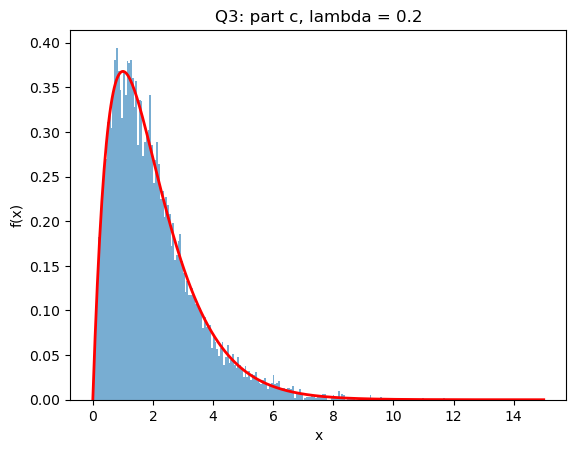

In [99]:
lam = 0.2
c = 1/(0.16)*np.e
N = 10**4

samples, acc_frac = run_accept_reject(lam, c, N)

x = np.linspace(0, 15, 400)
f = x * np.exp(-x)

plt.hist(samples, bins=200, density=True, alpha=0.6, label='Empirical pdf')
plt.plot(x, f, 'r-', linewidth=2, label='True Gamma(2,1) density')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Q3: part c, lambda = 0.2')
plt.show()

There is not a large difference between the fit of the histograms to f(x). However supplementing in a smaller lambda value causes the acceptance probability to lower. 

### Assignment 4 <br>
**part c**

In [88]:
rng = np.random.default_rng()
#parameters
a = 0.9
lam_f = 1000     
lam_s = 10       
N = 10**5

#step 1
U1 = rng.random(N)
U2 = rng.random(N)

#step 2
fast = U1 < a
lam = np.where(fast, lam_f, lam_s)

#step 3
T = -np.log(1 - U2)/lam

mean_theor = a/lam_f + (1 - a)/lam_s
mean_emp = np.mean(T)

tail_theor = a*np.exp(-lam_f*0.05) + (1 - a)*np.exp(-lam_s*0.05)
tail_emp = np.mean(T > 0.05)

print(f'empirical mean: {mean_emp}')
print(f'theoretical mean: {mean_theor}')
print(f'empirical P(T>.05): {tail_emp}')
print(f'theoretical P(T>.05): {tail_theor}')


empirical mean: 0.010927489197826629
theoretical mean: 0.010899999999999998
empirical P(T>.05): 0.06028
theoretical P(T>.05): 0.060653065971263326


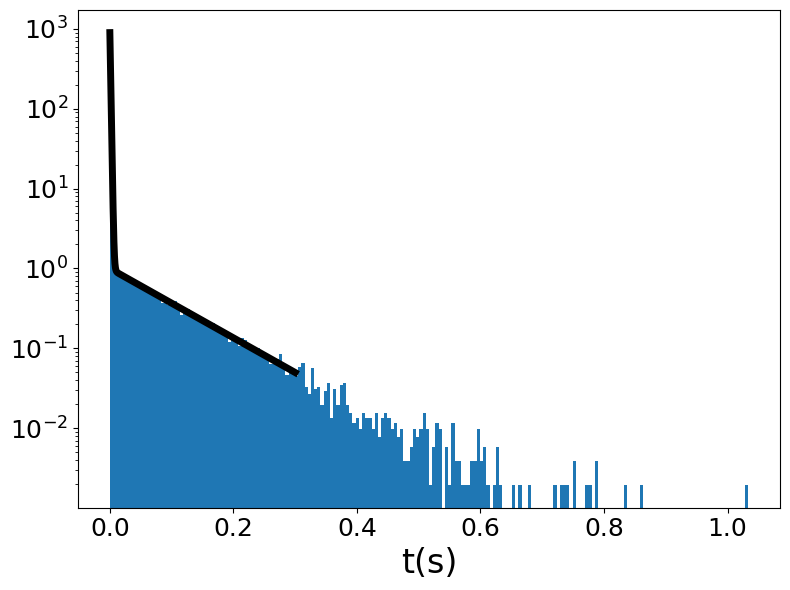

In [97]:
t_theor = np.linspace(1e-6, 0.3, 2000)
f_theor = a*lam_f*np.exp(-lam_f*t_theor) + (1 - a)*lam_s*np.exp(-lam_s*t_theor)

#normalized histogram
plt.figure(1, figsize=(8, 6))
plt.hist(T, bins=200, density=True)
plt.plot(t_theor, f_theor, 'k', linewidth=5)
plt.yscale('log')
plt.tick_params(labelsize=18)
plt.xlabel('t(s)', fontsize=24)
plt.tight_layout()
plt.show()

### Simulation Assignment 5 <br>


**part (b)**

In [90]:
rng = np.random.default_rng()
u = rng.random(100000)
z= 1 - np.sqrt(u)
print(z.mean())


0.33387917777519477


The sample mean from this inverse sampling method is extremely close to the expectation of 1/3 calculated in part a of this question.

**part (c)**

In [91]:
R = 1000
N_max = 10**4
C = np.full(R, 1)

for N in range(3, N_max):
    p = C / N
    U = rng.random(R)
    increase = U < p
    C = C + increase

z = C / N_max


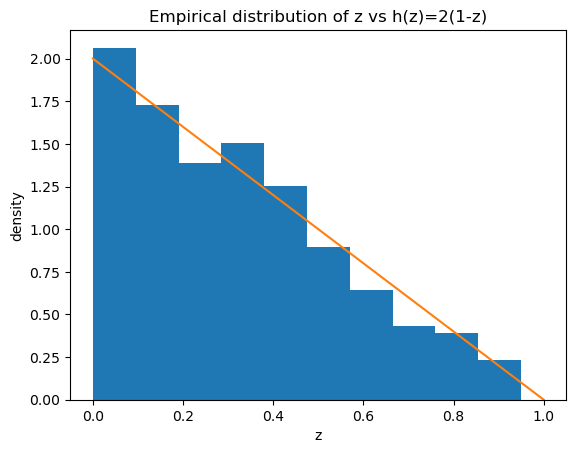

In [92]:
x = np.linspace(0, 1, 100)
y=2*(1-x)
plt.hist(z, density = True)
plt.plot(x, y)
plt.xlabel('z')
plt.ylabel('density')
plt.title('Empirical distribution of z vs h(z)=2(1-z)')
plt.show()

In [93]:
emp_mean = z.mean()
emp_ratio = z.std()/emp_mean
min_core = np.min(z)
max_core = np.max(z)
print(f'Empirical Mean: {emp_mean}')
print(f'Empirical Ration: {emp_ratio}')
print(f'Smallest core fraction: {min_core}')
print(f'Largest core fraction: {max_core}')


Empirical Mean: 0.32222580000000006
Empirical Ration: 0.7205314202836987
Smallest core fraction: 0.0001
Largest core fraction: 0.9499


The empirical mean from part a is 1/3 which very close to the empirical mean calculated here in part c which is about 0.3222. The empirical ratio in part at was $1/\sqrt{2}$ which is about 0.72 and matches closely to the empiracl ration in part c which is about 0.7 as well.<br>

The smallest core fraction is 0.0001 while the largest is 0.9499. This shows proportionally how leaf or core heavy the realizations are. Seeing how much these values vary we can see how the average core value cant give you exact information on how one singular network will turn out.